<a href="https://colab.research.google.com/github/kaveeshahq/research-project/blob/main/RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!pip install pandas numpy scikit-learn matplotlib seaborn joblib shap joblib imbalanced-learn xgboost lightgbm

In [7]:
import pandas as pd

print("--- Model Performance Metrics ---")
try:
    # These variables are defined in cell iMkuCSIRdjC9
    print(f"RMSE: {test_rmse:.4f}")
    print(f"MAE:  {test_mae:.4f}")
    print(f"R2:   {test_r2:.4f}")

    # Display the top features based on the best_model found in RandomizedSearchCV
    rf_model = best_model.named_steps['rf']
    fi_display = pd.DataFrame({
        'feature': X.columns.tolist(),
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)

    print("\n--- Top 5 Most Important Features ---")
    display(fi_display.head(5))
except NameError as e:
    print(f"Error: {e}. Please ensure you have run the training cell (iMkuCSIRdjC9) first.")

--- Model Performance Metrics ---
Error: name 'test_rmse' is not defined. Please ensure you have run the training cell (iMkuCSIRdjC9) first.


In [8]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
import joblib
import shap

sns.set(style="whitegrid")
RANDOM_STATE = 42

In [14]:
DATA_PATH = "/content/winequality-white.csv"   # Updated to match available file
MODEL_OUT = "rf_wine_regressor.joblib"
SHAP_OUT = "shap_summary.png"

In [17]:
import os

print("Loading dataset...")
# Check if the file exists before loading
if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH, sep=';')
    print("Dataset columns:", df.columns.tolist())
    print("Dataset shape:", df.shape)
    print("\nLabel distribution:")
    print(df['quality'].value_counts().sort_index())
else:
    print(f"Error: The file was not found at {DATA_PATH}. Please ensure you have uploaded the wine quality CSV to your Colab files.")

Loading dataset...
Dataset columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']
Dataset shape: (4898, 12)

Label distribution:
quality
3      20
4     163
5    1457
6    2198
7     880
8     175
9       5
Name: count, dtype: int64


In [13]:
try:
    df = df.copy()
    # Example engineered feature — acid ratio (interpretable)
    if 'fixed acidity' in df.columns and 'volatile acidity' in df.columns:
        df['acid_ratio'] = df['fixed acidity'] / (df['volatile acidity'] + 1e-6)
    print("Feature engineering complete.")
except NameError:
    print("Error: 'df' is not defined. Please ensure the dataset was loaded successfully in the previous cells.")

Error: 'df' is not defined. Please ensure the dataset was loaded successfully in the previous cells.


In [16]:
try:
    df = df.copy()
    # Example engineered feature — acid ratio (interpretable)
    if 'fixed acidity' in df.columns and 'volatile acidity' in df.columns:
        df['acid_ratio'] = df['fixed acidity'] / (df['volatile acidity'] + 1e-6)
    print("Feature engineering successful.")
except NameError:
    print("Error: 'df' is not defined. Please re-run the data loading cell (7FUWORJSYqOE) now that the file path is fixed.")

Error: 'df' is not defined. Please re-run the data loading cell (7FUWORJSYqOE) now that the file path is fixed.


In [18]:
TARGET = 'quality'
X = df.drop(columns=[TARGET])
y = df[TARGET].values

In [19]:
bins = [0, 4, 5, 6, 7, 11]   # adjust bins if necessary
y_binned = pd.cut(y, bins=bins, labels=False, include_lowest=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y_binned
)
print("Train / Test sizes:", X_train.shape, X_test.shape)

Train / Test sizes: (3918, 11) (980, 11)


In [20]:
pipe = Pipeline([
    #('scaler', StandardScaler()),   # RandomForest doesn't require scaling
    ('rf', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
])

In [21]:
def rmse_cv(model, X, y, cv):
    neg_mse = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=cv, n_jobs=-1)
    rmse = np.sqrt(-neg_mse)
    return rmse

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("Running baseline 5-fold CV (this may take a moment)...")
base_rmse = rmse_cv(pipe, X_train, y_train, cv)
print("Baseline CV RMSE per fold:", np.round(base_rmse, 3))
print("Baseline CV RMSE mean ± std:", np.round(base_rmse.mean(), 3), "±", np.round(base_rmse.std(), 3))

Running baseline 5-fold CV (this may take a moment)...
Baseline CV RMSE per fold: [0.628 0.626 0.649 0.593 0.61 ]
Baseline CV RMSE mean ± std: 0.621 ± 0.019


In [22]:
param_dist = {
    "rf__n_estimators": [100, 200, 400, 800],
    "rf__max_depth": [None, 6, 10, 20, 40],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 4],
    "rf__max_features": ['auto', 'sqrt', 0.3, 0.5]
}
rs = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=40,
    scoring='neg_mean_squared_error',
    cv=cv,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
print("Starting RandomizedSearchCV...")
rs.fit(X_train, y_train)
print("RandomizedSearchCV done. Best params:")
print(rs.best_params_)

best_model = rs.best_estimator_

Starting RandomizedSearchCV...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
RandomizedSearchCV done. Best params:
{'rf__n_estimators': 800, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 1, 'rf__max_features': 'sqrt', 'rf__max_depth': None}


In [23]:
y_pred_test = best_model.predict(X_test)
# Calculate Mean Squared Error first
mse = mean_squared_error(y_test, y_pred_test)
# Then calculate RMSE by taking the square root of MSE
test_rmse = np.sqrt(mse)
test_mae = mean_absolute_error(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)
print("\nTest set performance:")
print("RMSE:", round(test_rmse, 3))
print("MAE:", round(test_mae, 3))
print("R2:", round(test_r2, 3))


Test set performance:
RMSE: 0.62
MAE: 0.447
R2: 0.511


In [24]:
rf = best_model.named_steps['rf']
feat_names = X.columns.tolist()
fi = pd.DataFrame({'feature': feat_names, 'importance': rf.feature_importances_}).sort_values('importance', ascending=False)
print("\nTop features by model importance:")
print(fi.head(15))

# permutation importance (robust)
print("\nComputing permutation importance (may take a while)...")
perm = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
perm_df = pd.DataFrame({'feature': feat_names, 'perm_mean': perm.importances_mean}).sort_values('perm_mean', ascending=False)
print(perm_df.head(15))


Top features by model importance:
                 feature  importance
10               alcohol    0.164134
7                density    0.112825
1       volatile acidity    0.109507
5    free sulfur dioxide    0.104418
4              chlorides    0.083641
6   total sulfur dioxide    0.080302
3         residual sugar    0.078719
8                     pH    0.070779
2            citric acid    0.070581
0          fixed acidity    0.065509
9              sulphates    0.059586

Computing permutation importance (may take a while)...
                 feature  perm_mean
10               alcohol   0.283329
1       volatile acidity   0.132257
5    free sulfur dioxide   0.104019
7                density   0.091134
3         residual sugar   0.057748
4              chlorides   0.056275
2            citric acid   0.049953
6   total sulfur dioxide   0.049280
8                     pH   0.048342
0          fixed acidity   0.032626
9              sulphates   0.031685



Generating SHAP values (TreeExplainer)...
Saved SHAP summary to: shap_summary.png


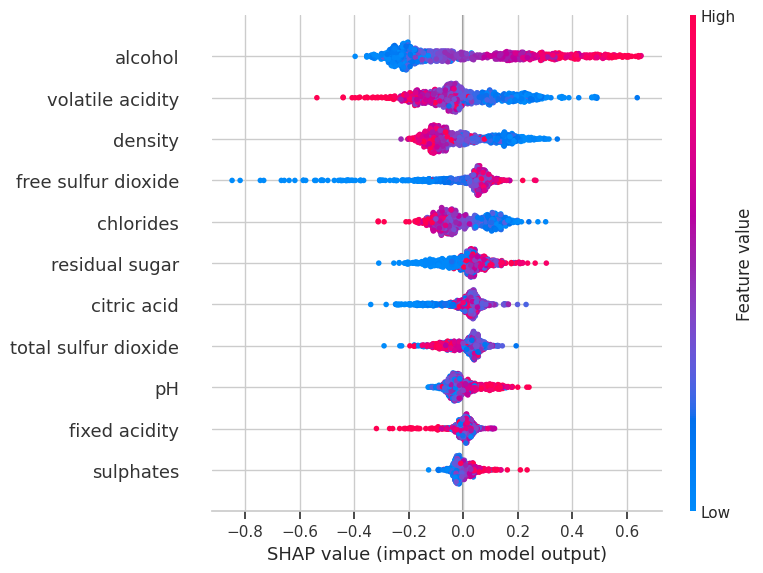

In [25]:
print("\nGenerating SHAP values (TreeExplainer)...")
explainer = shap.TreeExplainer(rf)
# Use all test rows or subsample for speed
X_shap = X_test if X_test.shape[0] <= 1000 else X_test.sample(1000, random_state=RANDOM_STATE)
shap_values = explainer.shap_values(X_shap)

# SHAP summary plot (saved to file)
plt.figure(figsize=(8,6))
shap.summary_plot(shap_values, X_shap, show=False)
plt.tight_layout()
plt.savefig(SHAP_OUT, dpi=200)
print("Saved SHAP summary to:", SHAP_OUT)

Top feature for PDP: alcohol


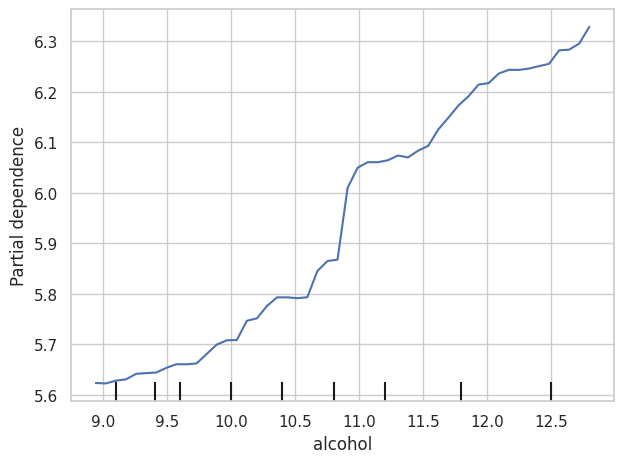

In [26]:
from sklearn.inspection import PartialDependenceDisplay
top_feature = fi.iloc[0]['feature']
print("Top feature for PDP:", top_feature)
_ = PartialDependenceDisplay.from_estimator(best_model, X_test, [top_feature], kind='average', grid_resolution=50)
plt.tight_layout()
plt.show()

In [27]:
joblib.dump({
    "pipeline": best_model,
    "feature_names": feat_names,
    "test_rmse": test_rmse,
    "test_mae": test_mae,
    "test_r2": test_r2
}, MODEL_OUT)
print("Saved pipeline and metadata to:", MODEL_OUT)

Saved pipeline and metadata to: rf_wine_regressor.joblib


In [28]:
sample = X_test.sample(5, random_state=RANDOM_STATE)
preds = best_model.predict(sample)
print("\nSample predictions:")
print(pd.concat([sample.reset_index(drop=True), pd.Series(preds, name='pred_quality')], axis=1))


Sample predictions:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            6.7              0.26         0.29             7.1      0.036   
1            6.6              0.26         0.46             6.9      0.047   
2            6.7              0.24         0.41             2.9      0.039   
3            6.6              0.30         0.25             8.0      0.036   
4            6.7              0.47         0.34             8.9      0.043   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 28.0                 100.0  0.99534  3.08       0.36   
1                 59.0                 183.0  0.99594  3.20       0.45   
2                 48.0                 122.0  0.99052  3.25       0.43   
3                 21.0                 124.0  0.99362  3.06       0.38   
4                 31.0                 172.0  0.99640  3.22       0.60   

   alcohol  pred_quality  
0      9.3       5.74625  
1      9.3 

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

lin_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

lin_pipe.fit(X_train, y_train)
lin_pred = lin_pipe.predict(X_test)

print("Linear Regression Performance:")
# In scikit-learn 1.4+, use root_mean_squared_error instead of mean_squared_error(..., squared=False)
print("RMSE:", root_mean_squared_error(y_test, lin_pred))
print("MAE: ", mean_absolute_error(y_test, lin_pred))
print("R2:  ", r2_score(y_test, lin_pred))

Linear Regression Performance:
RMSE: 0.7515995563520627
MAE:  0.5880858892730578
R2:   0.28083953501673375


In [31]:
import pandas as pd

results = pd.DataFrame({
    'Metric': ['RMSE (Lower is better)', 'MAE (Lower is better)', 'R2 Score (Higher is better)'],
    'Linear Regression': [0.7516, 0.5881, 0.2808],
    'Random Forest': [round(test_rmse, 4), round(test_mae, 4), round(test_r2, 4)]
})

print("--- Final Model Comparison ---")
display(results)

print("\nKey Insight:")
print(f"The Random Forest model reduced error (RMSE) by {round((0.7516 - test_rmse)/0.7516 * 100, 1)}% compared to the baseline.")

--- Final Model Comparison ---


,Metric,Linear Regression,Random Forest
0,RMSE (Lower is better),0.7516,0.6200
1,MAE (Lower is better),0.5881,0.4466
2,R2 Score (Higher is better),0.2808,0.5107



Key Insight:
The Random Forest model reduced error (RMSE) by 17.5% compared to the baseline.
